In [66]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [67]:
df = pd.read_csv("fifa_players.csv")
df.head(5)

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


Data Cleaning

In [68]:
df.isnull().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

In [69]:
df.shape

(17954, 51)

In [70]:
##check null values in percentage
null_percentages = (df.isnull().sum() / len(df)) * 100
print(null_percentages)

name                              0.000000
full_name                         0.000000
birth_date                        0.000000
age                               0.000000
height_cm                         0.000000
weight_kgs                        0.000000
positions                         0.000000
nationality                       0.000000
overall_rating                    0.000000
potential                         0.000000
value_euro                        1.420296
wage_euro                         1.370168
preferred_foot                    0.000000
international_reputation(1-5)     0.000000
weak_foot(1-5)                    0.000000
skill_moves(1-5)                  0.000000
body_type                         0.000000
release_clause_euro              10.231703
national_team                    95.226690
national_rating                  95.226690
national_team_position           95.226690
national_jersey_number           95.226690
crossing                          0.000000
finishing  

In [71]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print("Number of numerical features:",len(num_features))

cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print("Number of categorical features:",len(cat_features))

discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print("Number of discrete features:",len(discrete_features))

continuous_features = [feature for feature in num_features if feature not in discrete_features]
print("Number of continuous features:",len(continuous_features))

Number of numerical features: 42
Number of categorical features: 9
Number of discrete features: 5
Number of continuous features: 37


In [72]:
# Step 1: Clean column names
df.columns = df.columns.str.strip()

# Step 2: Separate column types
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# -------------------- NUMERIC IMPUTATION --------------------
if len(numeric_cols) > 0:
    null_count_num = df[numeric_cols].isnull().sum().sum()
    total_values_num = df[numeric_cols].shape[0] * len(numeric_cols)
    percentage_num = (null_count_num / total_values_num) * 100

    print(f"Numeric Nulls: {null_count_num}, Percentage: {percentage_num:.2f}%")

    if percentage_num <= 5:
        # Mean Imputation
        for col in numeric_cols:
            df[col] = df[col].fillna(df[col].mean())
        print("Numeric columns imputed using MEAN")

    else:
        # KNN Imputation
        from sklearn.impute import KNNImputer
        imputer = KNNImputer(n_neighbors=5)
        df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
        print("Numeric columns imputed using KNN")

# -------------------- CATEGORICAL IMPUTATION --------------------
if len(categorical_cols) > 0:
    for col in categorical_cols:
        mode_value = df[col].mode()[0]  # Most frequent value
        df[col] = df[col].fillna(mode_value)

    print("Categorical columns imputed using MODE")

# -------------------- FINAL CHECK --------------------
print("\nRemaining Null Values:")
print(df.isnull().sum())

Numeric Nulls: 36532, Percentage: 4.84%
Numeric columns imputed using MEAN
Categorical columns imputed using MODE

Remaining Null Values:
name                             0
full_name                        0
birth_date                       0
age                              0
height_cm                        0
weight_kgs                       0
positions                        0
nationality                      0
overall_rating                   0
potential                        0
value_euro                       0
wage_euro                        0
preferred_foot                   0
international_reputation(1-5)    0
weak_foot(1-5)                   0
skill_moves(1-5)                 0
body_type                        0
release_clause_euro              0
national_team                    0
national_rating                  0
national_team_position           0
national_jersey_number           0
crossing                         0
finishing                        0
heading_accuracy      

Feature Engineering

In [73]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to all categorical (string) columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Show result
print(df.head())

# Save encoded dataset
df.to_csv("fifa_label_encoded.csv", index=False)

    name  full_name  birth_date  age  height_cm  weight_kgs  positions  \
0   9536       9641        4372   31     170.18        72.1        214   
1   2446       2744        2109   27     154.94        76.2         72   
2  13031      13054        2641   25     190.50        83.9        228   
3   9421       9679        4512   27     162.56        59.0        549   
4   8675       8838        4310   27     187.96        88.9        104   

   nationality  overall_rating  potential  ...  long_shots  aggression  \
0            6              94         94  ...          94          48   
1           39              88         89  ...          89          46   
2           53              88         91  ...          82          78   
3           76              88         88  ...          84          34   
4          126              88         91  ...          15          87   

   interceptions  positioning  vision  penalties  composure  marking  \
0             22           94      94 

In [74]:
df.head(5)

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,9536,9641,4372,31,170.18,72.1,214,6,94,94,...,94,48,22,94,94,75,96,33,28,26
1,2446,2744,2109,27,154.94,76.2,72,39,88,89,...,89,46,56,84,91,67,88,59,57,22
2,13031,13054,2641,25,190.50,83.9,228,53,88,91,...,82,78,64,82,88,82,87,63,67,67
3,9421,9679,4512,27,162.56,59.0,549,76,88,88,...,84,34,26,83,87,61,83,51,24,22
4,8675,8838,4310,27,187.96,88.9,104,126,88,91,...,15,87,88,24,49,33,80,91,88,87


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# NEW: Grab text positions from the raw file
# ==========================================
df_raw = pd.read_csv('fifa_players.csv')
df['raw_positions'] = df_raw['positions']

# ==========================================
# 1. FEATURE SELECTION
# ==========================================
technical_cols = df.iloc[:, 21:50].columns.tolist()
physical_cols = ['height_cm', 'weight_kgs', 'age']
selected_cols = technical_cols + physical_cols

# ==========================================
# 2. GROUP THE POSITIONS
# ==========================================
position_mapping = {
    'ST': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'CF': 'Forward', 'RF': 'Forward', 'LF': 'Forward',
    'CAM': 'Midfielder', 'CM': 'Midfielder', 'CDM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'GK': 'Goalkeeper'
}

# Apply the mapping to the RAW text positions, not the encoded ones
df['Primary_Position'] = df['raw_positions'].apply(lambda x: str(x).split(',')[0])
df['Broad_Position'] = df['Primary_Position'].map(position_mapping)

# ==========================================
# 3. FILTER AND SPLIT
# ==========================================
# Create filtered dataframe using YOUR selected columns + the NEW broad position
df_filtered = df[selected_cols + ['Broad_Position']].dropna()

# Define X and y
X = df_filtered.drop(columns=['Broad_Position'])
y = df_filtered['Broad_Position']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,roc_auc_score,f1_score

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Then apply KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:

models = {
    "K-Nearest Neighbor": KNeighborsClassifier(
        n_neighbors=N3,
        weights='distance'
    ),
    "Random Forest": RandomForestClassifier(
        max_depth=15,          
        min_samples_split=10,  
        min_samples_leaf=5,    
        max_features='sqrt', 
        random_state=42
    )
}

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    ## Training performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
    model_train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)

    ## Testing performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred, average='weighted',zero_division=0)
    model_test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)

    print(name)

    print("Model Performance for Training set")
    print(f"- Accuracy: {model_train_accuracy:.4f}")
    print(f"- F1-score: {model_train_f1:.4f}")
    print(f"- Precision: {model_train_precision:.4f}")
    print(f"- Recall: {model_train_recall:.4f}")

    print("--------------------------------------------------")

    print("Model Performance for Testing set")
    print(f"- Accuracy: {model_test_accuracy:.4f}")
    print(f"- F1-score: {model_test_f1:.4f}")
    print(f"- Precision: {model_test_precision:.4f}")
    print(f"- Recall: {model_test_recall:.4f}")

    print("=" * 35)
    print("\n")

K-Nearest Neighbor
Model Performance for Training set
- Accuracy: 1.0000
- F1-score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
--------------------------------------------------
Model Performance for Testing set
- Accuracy: 0.8502
- F1-score: 0.8500
- Precision: 0.8508
- Recall: 0.8502


Random Forest
Model Performance for Training set
- Accuracy: 0.9569
- F1-score: 0.9567
- Precision: 0.9571
- Recall: 0.9569
--------------------------------------------------
Model Performance for Testing set
- Accuracy: 0.8906
- F1-score: 0.8897
- Precision: 0.8900
- Recall: 0.8906




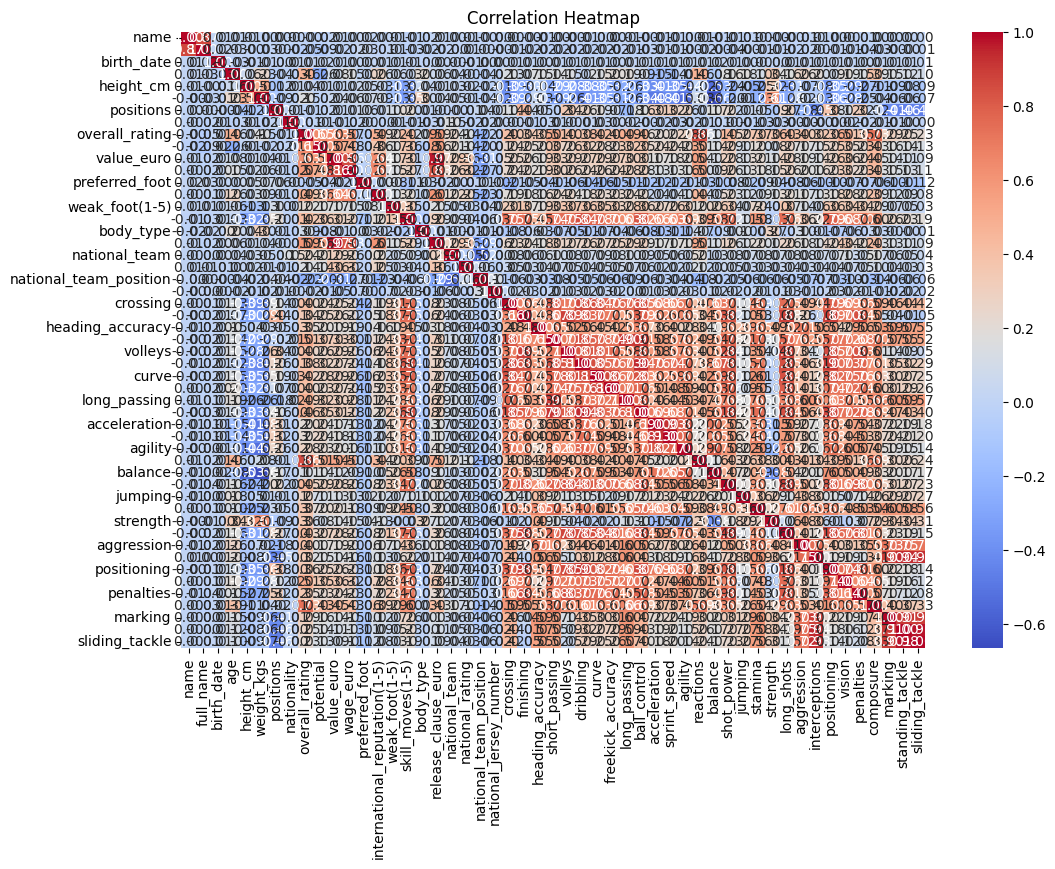

In [79]:
# Load dataset
df = pd.read_csv("fifa_label_encoded.csv")

# Use only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()